Author : Clara Martinez

Date : 02/04/2025

## **Streamlit**

Streamlit is an open-source Python library designed for creating and sharing data-driven web applications quickly and easily. It is particularly popular among data scientists and machine learning engineers because it allows them to transform data scripts into interactive web apps with minimal effort. Streamlit's simplicity lies in its intuitive API, which lets users build applications using familiar Python syntax without requiring extensive web development knowledge. Key features include the ability to display data frames, charts, and interactive widgets such as sliders, text inputs, and buttons. Streamlit automatically updates the app in real-time as the underlying code changes, making it ideal for rapid prototyping and iterative development. While Streamlit excels in ease of use and speed of deployment, it faces competition from other tools like Dash by Plotly and Shiny for R, which offer more customization and scalability options for complex applications. However, Streamlit's focus on simplicity and its active community make it a compelling choice for quickly building and deploying data applications.

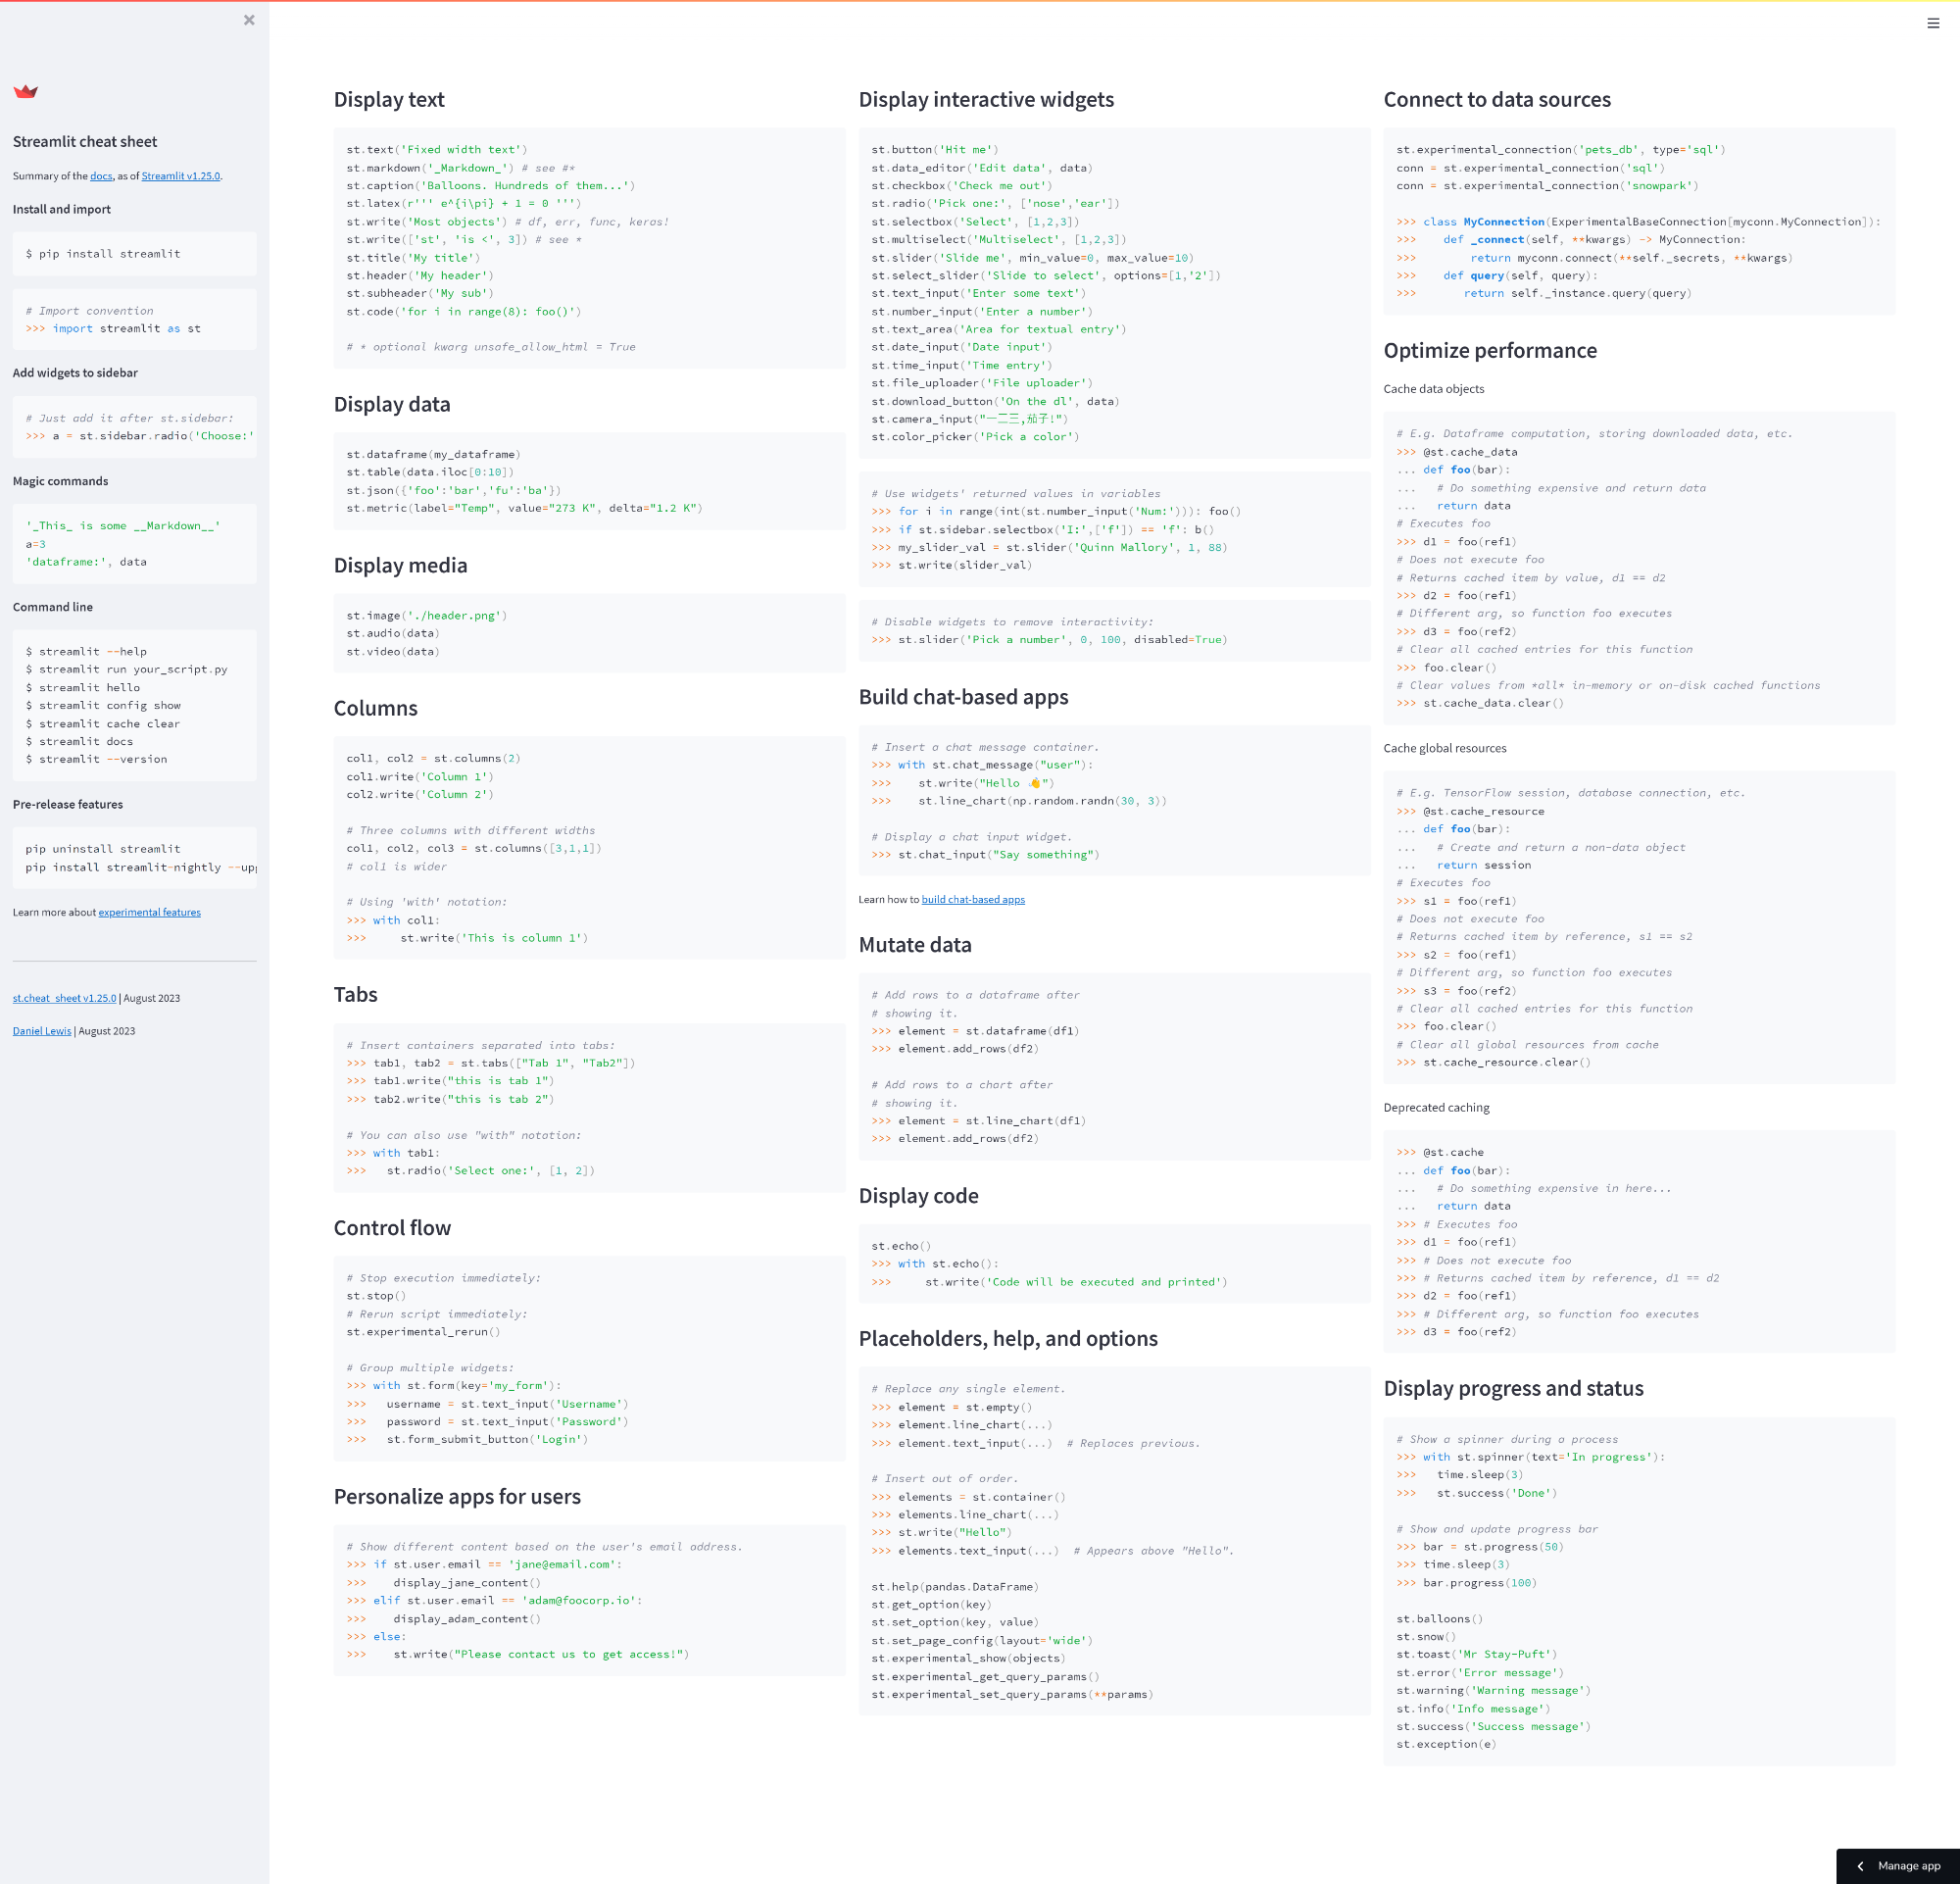

*Install Required Libraries*

In [1]:
!pip install streamlit ngrok

In [2]:
pip install pyngrok

*Write your Streamlit app to a file*

In [3]:
%%writefile app.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

st.title("Displaying Data in Streamlit")

# Displaying text
st.write("Here's some text:")
st.write("This is a paragraph.")

# Displaying a DataFrame
data = {'col1': [1, 2, 3, 4], 'col2': [10, 20, 30, 40]}
df = pd.DataFrame(data)
st.write("Here's a DataFrame:")
st.write(df)

# Displaying a chart
plt.plot(df['col1'], df['col2'])
st.pyplot(plt)

Overwriting app.py


In [12]:
# Add widgets
# Step 2: Write your Streamlit app to a file
%%writefile appw.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

st.title("Interactive Data Display with Streamlit")

# Displaying text
st.write("Here's some text:")
st.write("This is a paragraph.")

# Define the DataFrame
data = {'col1': [1, 2, 3, 4], 'col2': [10, 20, 30, 40]}
df = pd.DataFrame(data)

# Adding a slider to filter data
max_value = st.slider("Select maximum value for col1", min_value=1, max_value=4, value=4)
filtered_data = df[df['col1'] <= max_value]

# Displaying a DataFrame with a checkbox to toggle visibility
show_data = st.checkbox("Show DataFrame")
if show_data:
    st.write("Here's a filtered DataFrame:")
    st.write(filtered_data)

# Displaying a chart with a selectbox to choose the column for the x-axis
x_axis = st.selectbox("Select column for x-axis", options=filtered_data.columns)
plt.figure()
plt.plot(filtered_data[x_axis], filtered_data['col2'])
plt.title(f"Plot of {x_axis} vs col2")
st.pyplot(plt)

# Text input for user interaction
name = st.text_input("Enter your name", "Type here...")
st.write("Hello,", name)

Writing appw.py


*Running the app*

In [14]:
# First, create an ngrok account and second retrieve an authtoken on the website.

# Configurer votre authtoken
!ngrok config add-authtoken **privateKEY**

from pyngrok import ngrok

# Terminer les tunnels ouverts si nécessaire
ngrok.kill()

# Créer un nouveau tunnel HTTP sur le port 8501
public_url = ngrok.connect(8501, "http")
print(f"Streamlit app is live at {public_url}")

# Exécuter l'application Streamlit
!streamlit run appw.py &

# Garder le cellulaire actif pour maintenir le tunnel ngrok
import time
while True:
    time.sleep(1)

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml
Streamlit app is live at NgrokTunnel: "https://5942-34-48-66-53.ngrok-free.app" -> "http://localhost:8501"



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.48.66.53:8501

  Stopping...


KeyboardInterrupt: 

*Display*

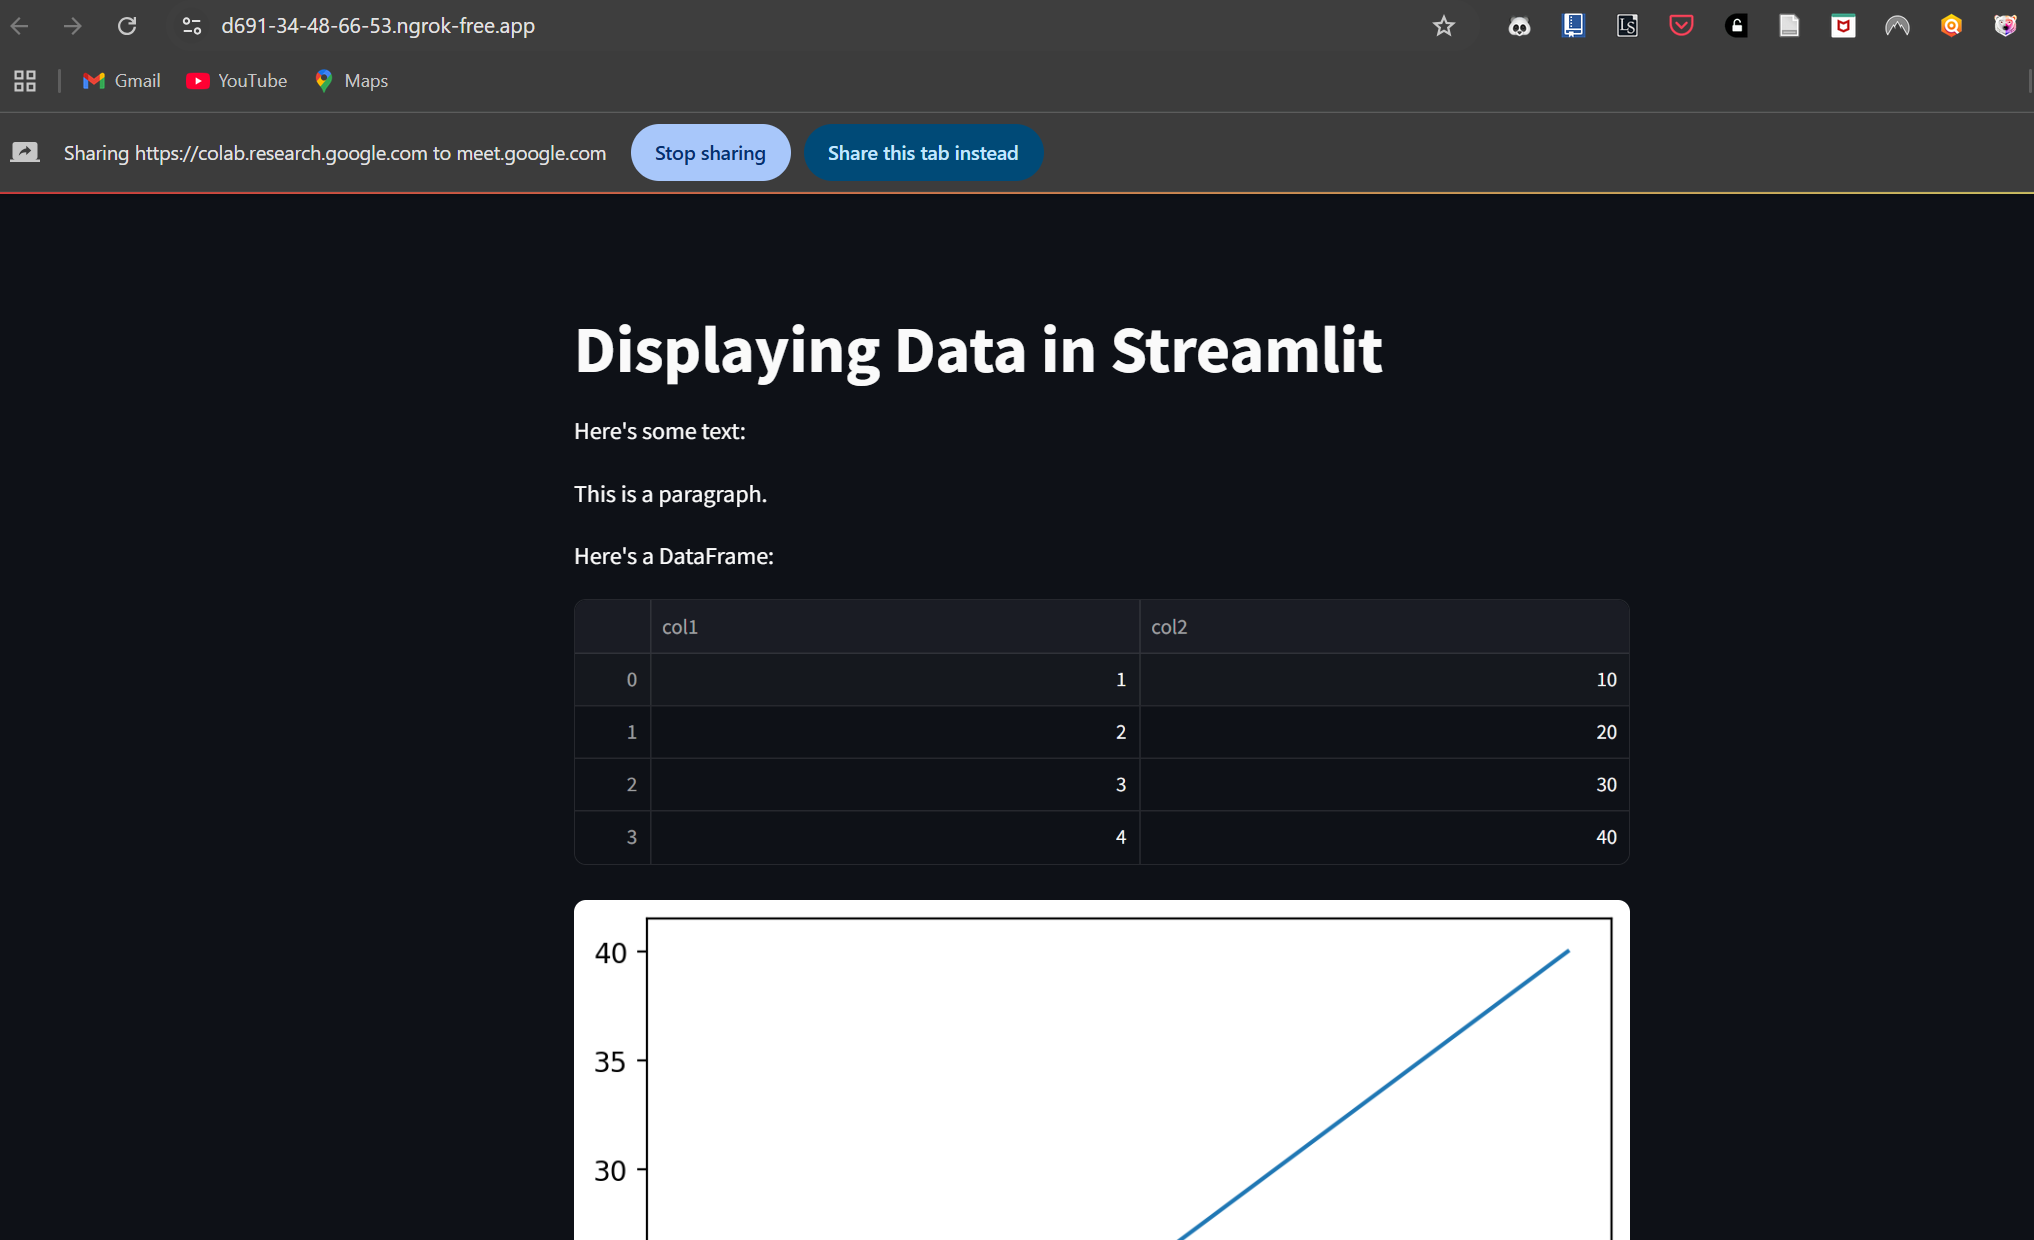

Ngrok is a versatile tool that provides secure tunnels to localhost, enabling developers to expose their local servers to the internet with ease. It is particularly useful for testing webhooks, APIs, and web applications in development environments, as it allows external access to local services without deploying them to a public server. Ngrok works by creating a secure tunnel from a public URL to a port on your local machine, effectively bypassing network restrictions and firewall configurations. This makes it an invaluable tool for developers who need to demonstrate or test applications remotely. Ngrok also offers features like request inspection, allowing developers to view and replay requests, which is beneficial for debugging. While Ngrok is widely used for its simplicity and reliability, it competes with other tunneling solutions like Localtunnel and Serveo, which offer similar functionalities. However, Ngrok's robust feature set, including authentication, custom subdomains, and detailed logging, makes it a preferred choice for many developers seeking a reliable and secure tunneling solution.

# Building GUI Chatbot with Streamlit

In [3]:
%%writefile chatapp.py
import streamlit as st
import random
import time

# Streamed response emulator
def response_generator():
    response = random.choice(
        [
            "Hello there! How can I assist you today?",
            "Hi, human! Is there anything I can help you with?",
            "Do you need help?",
        ]
    )
    for word in response.split():
        yield word + " "
        time.sleep(0.01)  # Reduced delay for faster response

st.title("Simple Chat")

# Initialize chat history
if "messages" not in st.session_state:
    st.session_state.messages = []

# Display chat messages from history on app rerun
for message in st.session_state.messages:
    with st.chat_message(message["role"]):
        st.markdown(message["content"])

# Accept user input
if prompt := st.chat_input("What is up?"):
    # Add user message to chat history
    st.session_state.messages.append({"role": "user", "content": prompt})
    # Display user message in chat message container
    with st.chat_message("user"):
        st.markdown(prompt)

    # Display assistant response in chat message container
    with st.chat_message("assistant"):
        response = "".join(response_generator())
        st.markdown(response)
    # Add assistant response to chat history
    st.session_state.messages.append({"role": "assistant", "content": response})

Writing chatapp.py


In [5]:
# Configurer votre authtoken
!ngrok config add-authtoken **privateKEY**

from pyngrok import ngrok

# Terminer les tunnels ouverts si nécessaire
ngrok.kill()

# Créer un nouveau tunnel HTTP sur le port 8501
public_url = ngrok.connect(8501, "http")
print(f"Streamlit app is live at {public_url}")

# Exécuter l'application Streamlit
!streamlit run chatapp.py &

# Garder le cellulaire actif pour maintenir le tunnel ngrok
import time
while True:
    time.sleep(1)

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml
Streamlit app is live at NgrokTunnel: "https://5ff3-34-48-66-53.ngrok-free.app" -> "http://localhost:8501"



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.48.66.53:8501

  Stopping...


KeyboardInterrupt: 

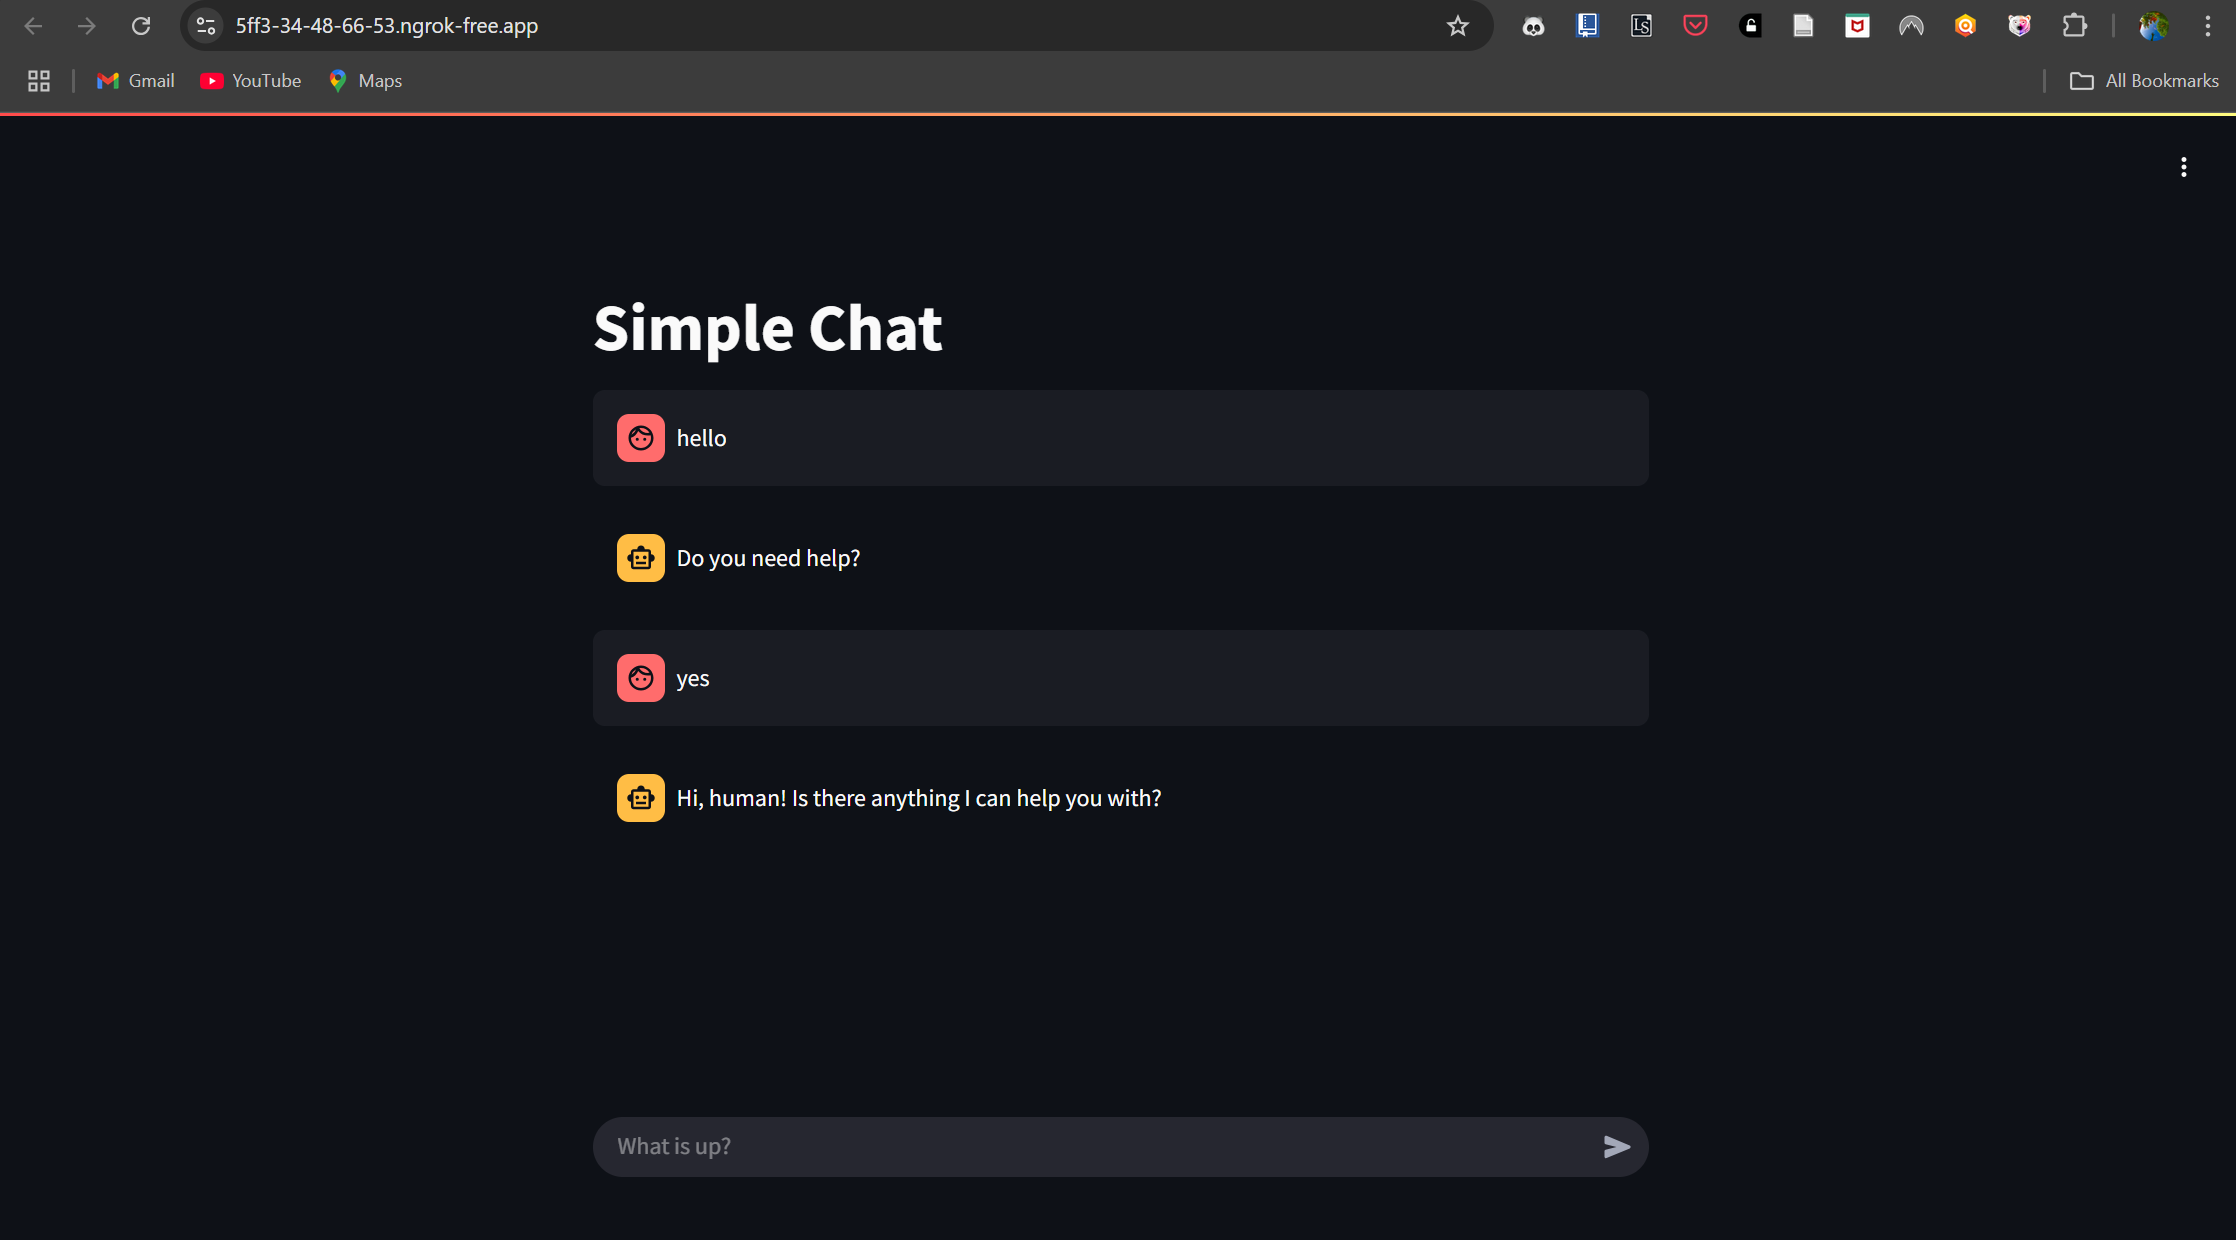

Build a ChatGPT-like app

In [6]:
pip install streamlit transformers

In [2]:
%%writefile GPTapp.py
import streamlit as st
from transformers import pipeline

st.title("ChatGPT-like Clone with Hugging Face")

# Load a text-generation model from Hugging Face
@st.cache_resource
def load_model():
    return pipeline("text-generation", model="microsoft/DialoGPT-medium")

model = load_model()

# Initialize chat history
if "messages" not in st.session_state:
    st.session_state.messages = []

# Display chat messages from history on app rerun
for message in st.session_state.messages:
    with st.chat_message(message["role"]):
        st.markdown(message["content"])

# Accept user input
if prompt := st.chat_input("What is up?"):
    # Add user message to chat history
    st.session_state.messages.append({"role": "user", "content": prompt})
    # Display user message in chat message container
    with st.chat_message("user"):
        st.markdown(prompt)

    # Generate response using the Hugging Face model
    response = model(prompt, max_length=100, num_return_sequences=1)[0]['generated_text']

    # Display assistant response in chat message container
    with st.chat_message("assistant"):
        st.markdown(response)
    # Add assistant response to chat history
    st.session_state.messages.append({"role": "assistant", "content": response})

Overwriting GPTapp.py


Model Loading: The load_model function uses the transformers library to load a conversational model. Here, we use microsoft/DialoGPT-medium, a popular conversational model.

Caching: The @st.cache decorator is used to cache the model loading process, which speeds up the app by preventing the model from being loaded multiple times.

Chat History: The app maintains a chat history using st.session_state, which allows the conversation to persist across reruns.
User Interaction: The app captures user input using st.chat_input and displays both user and model responses using st.chat_message.

In [3]:
# Configurer votre authtoken
!ngrok config add-authtoken **privateKEY**

from pyngrok import ngrok

# Terminer les tunnels ouverts si nécessaire
ngrok.kill()

# Créer un nouveau tunnel HTTP sur le port 8501
public_url = ngrok.connect(8501, "http")
print(f"Streamlit app is live at {public_url}")

# Exécuter l'application Streamlit
!streamlit run GPTapp.py &

# Garder le cellulaire actif pour maintenir le tunnel ngrok
import time
while True:
    time.sleep(1)

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml
Streamlit app is live at NgrokTunnel: "https://ce49-34-48-66-53.ngrok-free.app" -> "http://localhost:8501"



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.48.66.53:8501

2025-04-02 09:59:36.001821: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743587976.032533   26232 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743587976.041779   26232 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-02 09:59:36.071087: I tensorflow/core/platform/cpu_feature_guard.cc:210] This T

KeyboardInterrupt: 

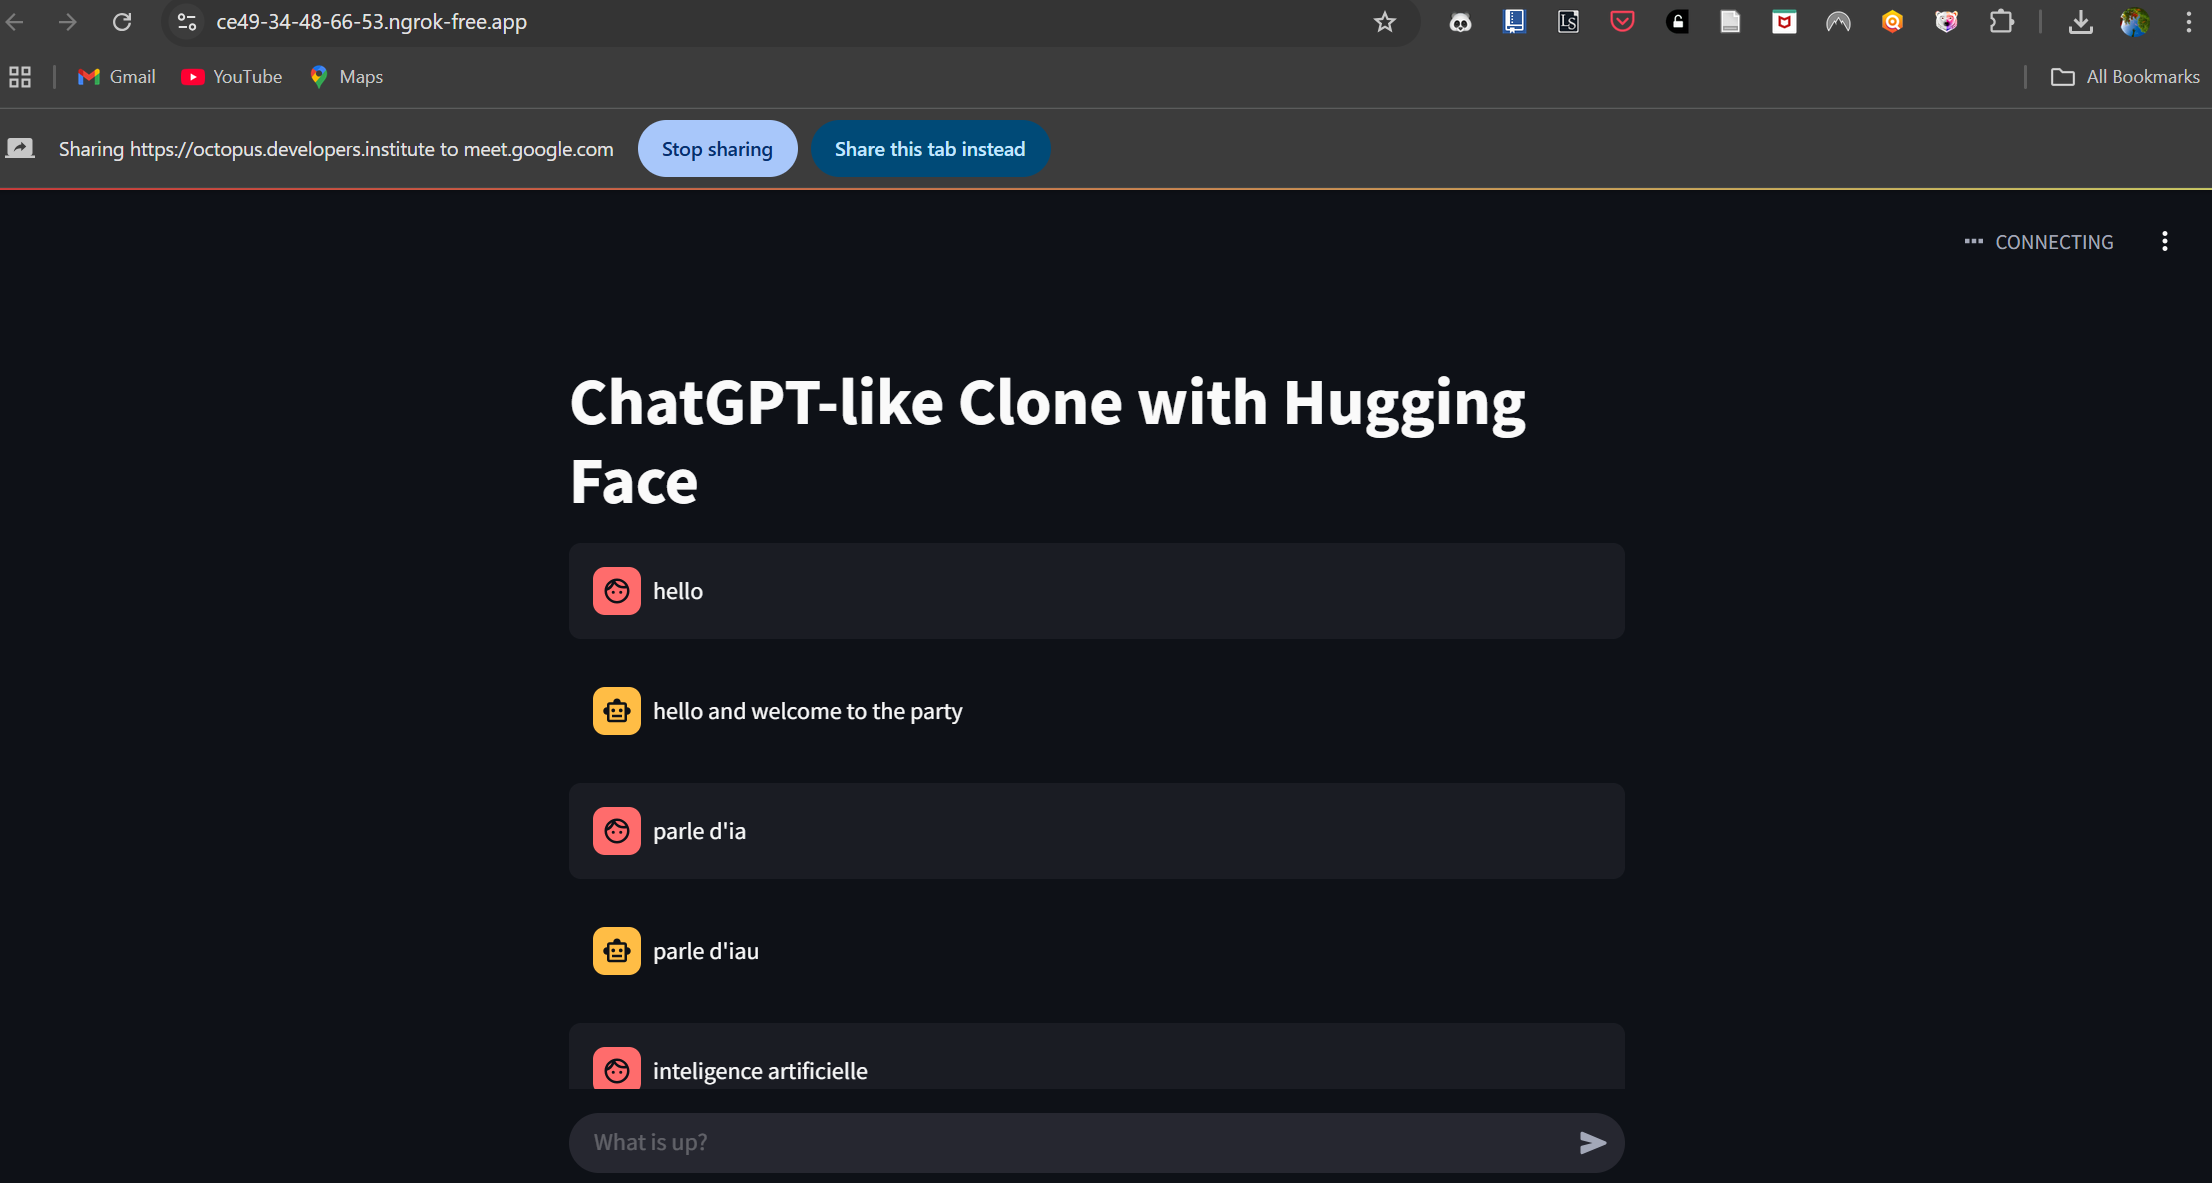

The **microsoft/DialoGPT-medium** model is a conversational AI model developed by Microsoft, based on the GPT-2 architecture. It is part of the DialoGPT family, which is specifically fine-tuned for dialogue generation tasks.

*Architecture*

Based on GPT-2: DialoGPT is built on top of the GPT-2 architecture, which is a transformer-based model known for its ability to generate coherent and contextually relevant text.
Medium Size: The "medium" variant of DialoGPT is a middle-sized model in the family, balancing performance and computational efficiency. It has more parameters than the "small" version but fewer than the "large" version.
Training:

Fine-tuned for Conversations: Unlike the original GPT-2, which was trained on a wide range of internet text, DialoGPT is fine-tuned specifically for conversational data. This makes it more adept at generating dialogue that mimics human conversation.
Dataset: The model was trained on a large dataset of conversational exchanges, which helps it understand and generate responses that are contextually appropriate in a dialogue setting.

*Training*

Fine-tuned for Conversations: Unlike the original GPT-2, which was trained on a wide range of internet text, DialoGPT is fine-tuned specifically for conversational data. This makes it more adept at generating dialogue that mimics human conversation.

Dataset: The model was trained on a large dataset of conversational exchanges, which helps it understand and generate responses that are contextually appropriate in a dialogue setting.

*Use Cases*

Chatbots: Ideal for building chatbots and virtual assistants that require natural language understanding and generation capabilities.

Interactive Applications: Can be used in applications where user interaction through text is required, such as customer support, entertainment, and educational tools.

## **Building Conversational Chatbots with Gradio**

Gradio is an open-source Python library designed to simplify the process of creating user-friendly web interfaces for machine learning models and data science workflows. It allows developers and researchers to quickly build interactive demos and applications without requiring extensive web development skills. With Gradio, you can create interfaces that enable users to input data, interact with models, and visualize outputs in real-time. This is particularly useful for showcasing machine learning models, as it provides an intuitive way for users to test and understand model behavior. Gradio supports a wide range of input and output types, including text, images, audio, and video, making it versatile for various applications. Additionally, Gradio can be easily integrated with popular machine learning frameworks like TensorFlow, PyTorch, and Hugging Face Transformers. Once an interface is created, it can be shared with others via a public link, facilitating collaboration and feedback. This ease of use and accessibility makes Gradio a valuable tool for both prototyping and deploying machine learning applications.

To build a voice-enabled conversational chatbot using Gradio in Google Colab, you'll need to follow a series of steps to set up the environment, process audio input, generate responses, and create the Gradio interface.

*Install Required Libraries*

In [1]:
!pip install gradio pydub numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 MB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.2/322.2 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 5.0 MB/s eta 0:00:00


*Import Necessary Module*

In [5]:
import gradio as gr
import numpy as np
import io
import tempfile
from pydub import AudioSegment
from dataclasses import dataclass, field
import numpy as np

*Define Helper Functions*

To manage the state of your application

In [6]:
@dataclass
class AppState:
    stream: np.ndarray | None = None
    sampling_rate: int = 0
    pause_detected: bool = False
    stopped: bool = False
    conversation: list = field(default_factory=list)

*Process User Audio*

To handle microphone input and detect pauses

In [7]:
def process_audio(audio: tuple, state: AppState):
    if state.stream is None:
        state.stream = audio[1]
        state.sampling_rate = audio[0]
    else:
        state.stream = np.concatenate((state.stream, audio[1]))

    # Placeholder for pause detection logic
    pause_detected = False  # Implement your pause detection logic here
    state.pause_detected = pause_detected

    if state.pause_detected and state.started_talking:
        return gr.Audio(recording=False), state
    return None, state

*Generate the Response*

To generate and stream the chatbots response

In [8]:
def response(state: AppState):
    if not state.pause_detected and not state.started_talking:
        return None, AppState()

    audio_buffer = io.BytesIO()

    segment = AudioSegment(
        state.stream.tobytes(),
        frame_rate=state.sampling_rate,
        sample_width=state.stream.dtype.itemsize,
        channels=(1 if len(state.stream.shape) == 1 else state.stream.shape[1]),
    )
    segment.export(audio_buffer, format="wav")

    with tempfile.NamedTemporaryFile(suffix=".wav", delete=False) as f:
        f.write(audio_buffer.getvalue())

    state.conversation.append({"role": "user",
                                "content": {"path": f.name,
                                "mime_type": "audio/wav"}})

    output_buffer = b""

    # Placeholder for generating response
    for mp3_bytes in speaking(audio_buffer.getvalue()):  # Implement your speaking function
        output_buffer += mp3_bytes
        yield mp3_bytes, state

    with tempfile.NamedTemporaryFile(suffix=".mp3", delete=False) as f:
        f.write(output_buffer)

    state.conversation.append({"role": "assistant",
                    "content": {"path": f.name,
                                "mime_type": "audio/mp3"}})
    yield None, AppState(conversation=state.conversation)

*Create the Gradio Interface*

Use Gradios Blocks API to set up the interface

In [10]:
def start_recording_user(state: AppState):
    if not state.stopped:
        return gr.Audio(recording=True)

with gr.Blocks() as demo:
    with gr.Row():
        with gr.Column():
            input_audio = gr.Audio(
                label="Input Audio", sources="microphone", type="numpy"
            )
        with gr.Column():
            chatbot = gr.Chatbot(label="Conversation", type="messages")
            output_audio = gr.Audio(label="Output Audio", streaming=True, autoplay=True)
    state = gr.State(value=AppState())

    stream = input_audio.stream(
        process_audio,
        [input_audio, state],
        [input_audio, state],
        stream_every=0.5,
        time_limit=30,
    )
    respond = input_audio.stop_recording(
        response,
        [state],
        [output_audio, state]
    )
    respond.then(lambda s: s.conversation, [state], [chatbot])

    restart = output_audio.stop(
        start_recording_user,
        [state],
        [input_audio]
    )
    cancel = gr.Button("Stop Conversation", variant="stop")
    cancel.click(lambda: (AppState(stopped=True), gr.Audio(recording=False)), None,
                [state, input_audio], cancels=[respond, restart])

if __name__ == "__main__":
    demo.launch(debug=True)

Running Gradio in a Colab notebook requires sharing enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://d4146021db614f96c8.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://1a8b70bd87eb92be6d.gradio.live
Killing tunnel 127.0.0.1:7861 <> https://d4146021db614f96c8.gradio.live


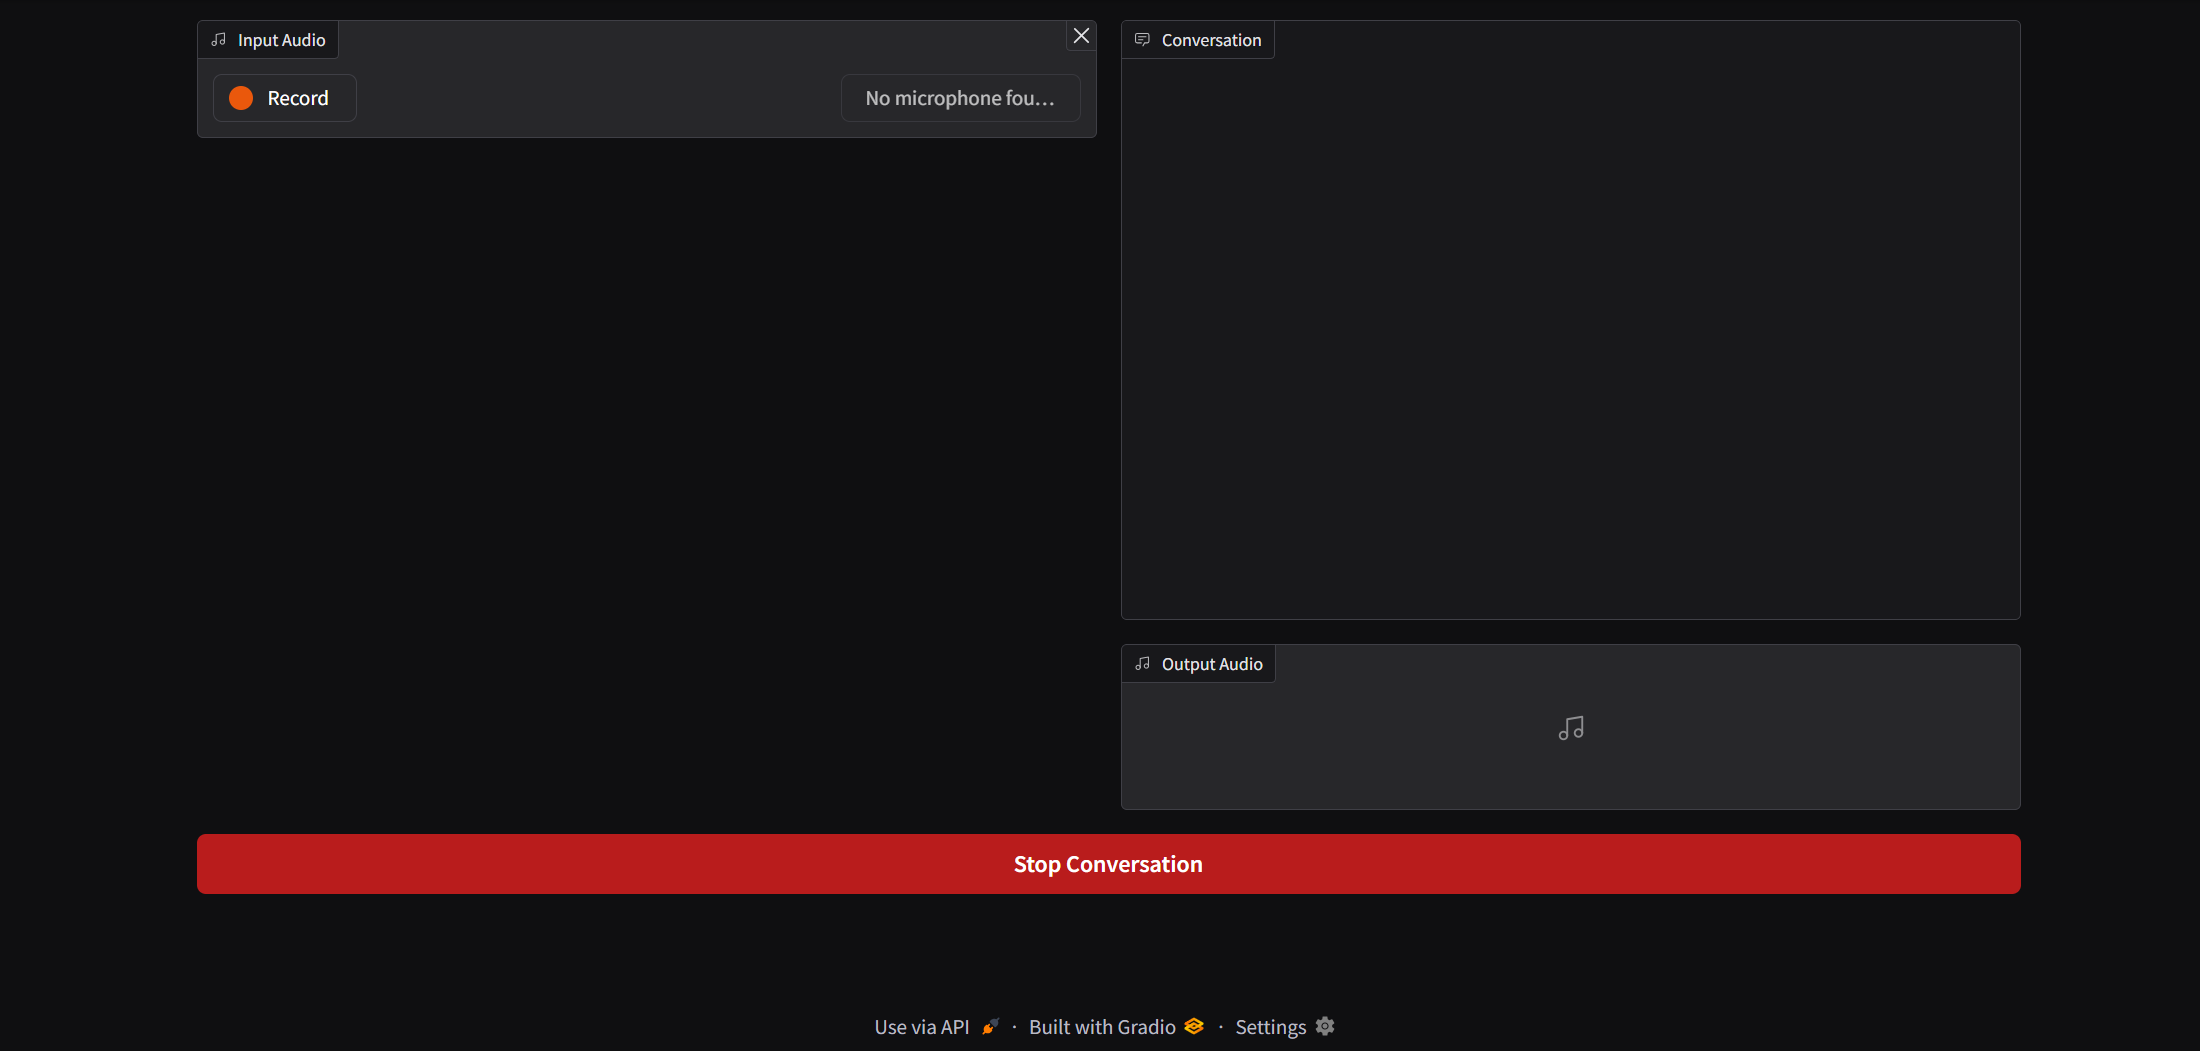